### import

In [1]:
import os
import sys
import re
import random
import numpy as np
import pandas as pd
import datetime as dt
from tqdm import tqdm
from matplotlib import pyplot as plt

from multiprocessing import Pool
from multiprocessing import cpu_count

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
path_timeseries = "../Data/Output"

### Read csv files

In [3]:
def dataframe_from_csv(path, header=0, index_col=False):
    return pd.read_csv(path, header=header, index_col=index_col)

In [4]:
def filter_on_variabels(all_series, all_variables):
    all_series = all_series[all_variables]
    all_series.reset_index(drop=True, inplace=True)
    return all_series

### Select Variables

In [5]:
columns = ['ICUSTAY_ID', 'Bins', 'Heart Rhythm', 'Heart Rate', 'SpO2', 'SvO2', 'Oxygen Saturation',
           'Respiratory Rate', 'Respiratory Rate (Total)', 'Respiratory Rate (Set)', 'Temperature',
           'Skin Temperature', 'Non Invasive Blood Pressure mean', 'Non Invasive Blood Pressure systolic',
           'Non Invasive Blood Pressure diastolic', 'Arterial Blood Pressure mean',
           'Arterial Blood Pressure systolic', 'Arterial Blood Pressure diastolic',
           'Glucose', 'Creatinine',  'Base Excess', 'BUN', 'Anion Gap',  'Bicarbonate',  'Lactate',  
           'Lactate Dehydrogenase (LD)', 'Hemoglobin', 'Hematocrit', 'pH', 'Bilirubin, Direct',   
           'Bilirubin, Indirect',  'Bilirubin, Total', 'pO2', 'pCO2',  'PT', 'PTT', 'INR(PT)', 'AST', 'ALT',
           'WBC', 'RBC',  'RDW', 'White Blood Cells', 'Red Blood Cells', 'Platelet Count', 'MCV',  'MCH', 'MCHC',
           'Potassium', 'Sodium', 'Chloride', 'Magnesium', 'Phosphate', 'Alkaline Phosphatase', 'Ionized Calcium',
           'Calcium non-ionized', 'Calcium, Total', 'Protein', 'Total Protein', 'Cholesterol, Total', 
           'Cholesterol, LDL', 'Cholesterol, HDL', 'Differential-Bands', 'Differential-Monos',
           'Differential-Lymphs', 'Differential-Eos', 'Differential-Basos', 'Differential-Neuts',
           'Differential-Polys', 'Oxygen', 'O2 Flow', 'Total CO2', 'ETCO2', 'Flow Rate (L/min)',
           'Mean Airway Pressure', 'Plateau Pressure', 'CVP',  'Amylase', 'Albumin', 'Fibrinogen',
           'Triglycerides', 'Transferrin', 'Ferritin', 'Troponin T', 'Troponin I', 'Vancomycin',
           'Vancomycin (Trough)', 'Vancomycin (Random)',  'Vancomycin (Peak)', 'C-Reactive Protein (CRP)',
           'GCS Total', 'GCS - Eye Opening',  'GCS - Verbal Response', 'GCS - Motor Response',
           'Richmond-RAS Scale', 'Goal Richmond-RAS Scale', 'Pain Present', 'Pain Level', 'Mental status',
           'Risk for Falls',  'Delirium assessment',  'CAM-ICU MS Change', 'CAM-ICU Inattention',
           'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC', 'CAM-ICU Altered LOC', 
           'FiO2', 'FiO2 (Set)', 'PEEP', 'PEEP (Set)', 'Tidal Volume', 'Tidal Volume (Set)', 'Ventilation Rate',
           'Intubated', 'Ventilator', 'Ventilator Mode', 'Ventilator Type',  'UrineOutput_IO',
           'Mg-nonIV_IO', 'Insulin_IO', 'K-IV_IO', 'Propofol_IO', 'Heparin_IO', 'Vasopressors_IO',
           'Fentanyl_IO', 'Crystalloids_IO', 'Vancomycin_IO', 'P.O._IO', 'Dextrose_IO',
           'Norepinephrine_PRC', 'Fentanyl_PRC', 'Antibiotic_PRC', 'Heparin_PRC', 'Insulin_PRC',
           'Propofol_PRC', 'Phenylephrine_PRC', 'Vasopressin_PRC', 'Epinephrine_PRC', 'Pantoprazole_PRC',
           'Microbio Test', 'Blood Culture', 
           'Note', 'Discharge_Note',
           'AGE', 'GENDER', 'ETHNICITY', 'Weight', 'Height',
           'SUBJECT_ID', 'HADM_ID', 'INTIME', 'OUTTIME', 'ADMITTIME', 'DISCHTIME', 'ICU_LOS_H', 'ICU_LOS_D',
           'HOSP_LOS_H', 'HOSP_LOS_D', 'ICU_EXPIRE_FLAG', 'HOSPITAL_EXPIRE_FLAG', 'EXPIRE_FLAG', 
           'DEATH_TIME_DISCH']

In [6]:
dynamic_var = ['Heart Rate', 'SpO2', 'SvO2', 'Oxygen Saturation',
               'Respiratory Rate', 'Respiratory Rate (Total)', 'Respiratory Rate (Set)', 'Temperature',
               'Skin Temperature', 'Non Invasive Blood Pressure mean', 'Non Invasive Blood Pressure systolic',
               'Non Invasive Blood Pressure diastolic', 'Arterial Blood Pressure mean',
               'Arterial Blood Pressure systolic', 'Arterial Blood Pressure diastolic',
               'Glucose', 'Creatinine',  'Base Excess', 'BUN', 'Anion Gap',  'Bicarbonate',  'Lactate',  
               'Lactate Dehydrogenase (LD)', 'Hemoglobin', 'Hematocrit', 'pH', 'Bilirubin, Direct',   
               'Bilirubin, Indirect',  'Bilirubin, Total', 'pO2', 'pCO2',  'PT', 'PTT', 'INR(PT)', 'AST', 'ALT',
               'WBC', 'RBC',  'RDW', 'White Blood Cells', 'Red Blood Cells','Platelet Count', 'MCV',  'MCH', 'MCHC',
               'Potassium', 'Sodium', 'Chloride', 'Magnesium', 'Phosphate','Alkaline Phosphatase','Ionized Calcium',
               'Calcium non-ionized', 'Calcium, Total', 'Protein', 'Total Protein', 'Cholesterol, Total', 
               'Cholesterol, LDL', 'Cholesterol, HDL', 'Differential-Bands', 'Differential-Monos',
               'Differential-Lymphs', 'Differential-Eos', 'Differential-Basos', 'Differential-Neuts',
               'Differential-Polys', 'Oxygen', 'O2 Flow', 'Total CO2', 'ETCO2', 'Flow Rate (L/min)',
               'Mean Airway Pressure', 'Plateau Pressure', 'CVP',  'Amylase', 'Albumin', 'Fibrinogen',
               'Triglycerides', 'Transferrin', 'Ferritin', 'Troponin T', 'Troponin I', 'Vancomycin',
               'Vancomycin (Trough)', 'Vancomycin (Random)',  'Vancomycin (Peak)', 'C-Reactive Protein (CRP)',
               'GCS Total', 'GCS - Eye Opening',  'GCS - Verbal Response', 'GCS - Motor Response',
               'Richmond-RAS Scale', 'Goal Richmond-RAS Scale', 'Pain Present', 'Pain Level', 'Mental status',
               'Risk for Falls',  'Delirium assessment',  'CAM-ICU MS Change', 'CAM-ICU Inattention',
               'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC', 'CAM-ICU Altered LOC', 
               'FiO2', 'FiO2 (Set)', 'PEEP', 'PEEP (Set)', 'Tidal Volume', 'Tidal Volume (Set)', 'Ventilation Rate',
               'Intubated', 'Microbio Test', 'Blood Culture', 'UrineOutput_IO',
               'Mg-nonIV_IO', 'Insulin_IO', 'K-IV_IO', 'Propofol_IO', 'Heparin_IO', 'Vasopressors_IO',
               'Fentanyl_IO', 'Crystalloids_IO', 'Vancomycin_IO', 'P.O._IO', 'Dextrose_IO',]

prescription = ['Norepinephrine_PRC', 'Fentanyl_PRC', 'Antibiotic_PRC', 'Heparin_PRC', 'Insulin_PRC',
                'Propofol_PRC', 'Phenylephrine_PRC', 'Vasopressin_PRC', 'Epinephrine_PRC', 'Pantoprazole_PRC',]

vital_columns = ['Heart Rate', 'Temperature', 'Respiratory Rate', 'SpO2', 'Oxygen Saturation',
                 'Non Invasive Blood Pressure mean', 'Non Invasive Blood Pressure diastolic', 
                 'Non Invasive Blood Pressure systolic' , 'Arterial Blood Pressure mean',
                 'Arterial Blood Pressure diastolic', 'Arterial Blood Pressure systolic']

### Variable Estimation

In [7]:
def estimate_gcs(rass):
    
    if   rass >=  0: return 15
    elif rass == -1: return 14
    elif rass == -2: return 12
    elif rass == -3: return 11
    elif rass == -4: return 6
    elif rass == -5: return 3
    
    return pd.NA

In [8]:
def variable_estimation(all_series):
    
    gcs_miss = ~pd.isna(all_series.loc[:, 'Richmond-RAS Scale']) & pd.isna(all_series['GCS Total'])
    all_series.loc[gcs_miss, 'GCS Total'] = all_series.loc[gcs_miss, 'Richmond-RAS Scale'].apply(estimate_gcs)

    ii = ~pd.isna(all_series.loc[:, 'Hemoglobin']) & pd.isna(all_series.loc[:, 'Hematocrit'])
    all_series.loc[ii, 'Hematocrit'] = (all_series.loc[ii, 'Hemoglobin'] * 2.862) + 1.216

    ii = ~pd.isna(all_series.loc[:, 'Hematocrit']) & pd.isna(all_series.loc[:, 'Hemoglobin'])
    all_series.loc[ii, 'Hemoglobin'] = (all_series.loc[ii, 'Hematocrit'] - 1.216) / 2.862

    ii = ~pd.isna(all_series.loc[:, 'Bilirubin, Total']) & pd.isna(all_series.loc[:, 'Bilirubin, Direct'])
    all_series.loc[ii, 'Bilirubin, Direct'] = (all_series.loc[ii, 'Bilirubin, Total'] * 0.6934) - 0.1752

    ii = ~pd.isna(all_series.loc[:, 'Bilirubin, Direct']) & pd.isna(all_series.loc[:, 'Bilirubin, Total'])
    all_series.loc[ii, 'Bilirubin, Total'] = (all_series.loc[ii, 'Bilirubin, Direct'] + 0.1752) / 0.6934

    ii = ~pd.isna(all_series.loc[:, 'Bilirubin, Indirect']) & pd.isna(all_series.loc[:, 'Bilirubin, Total'])
    all_series.loc[ii, 'Bilirubin, Total'] = (all_series.loc[ii, 'Bilirubin, Indirect'] + 0.1752) / 0.6934

    ii = ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure systolic']) & ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure mean']) & pd.isna(all_series.loc[:, 'Arterial Blood Pressure diastolic'])
    all_series.loc[ii, 'Arterial Blood Pressure diastolic'] = (3 * all_series.loc[ii, 'Arterial Blood Pressure mean'] - all_series.loc[ii, 'Arterial Blood Pressure systolic']) / 2

    ii = ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure systolic']) & ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure diastolic']) & pd.isna(all_series.loc[:, 'Arterial Blood Pressure mean'])
    all_series.loc[ii, 'Arterial Blood Pressure mean'] = (all_series.loc[ii, 'Arterial Blood Pressure systolic'] + 2 * all_series.loc[ii, 'Arterial Blood Pressure diastolic']) / 3

    ii = ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure mean']) & ~pd.isna(all_series.loc[:, 'Arterial Blood Pressure diastolic']) & pd.isna(all_series.loc[:, 'Arterial Blood Pressure systolic'])
    all_series.loc[ii, 'Arterial Blood Pressure systolic'] = 3 * all_series.loc[ii, 'Arterial Blood Pressure mean'] - 2 * all_series.loc[ii, 'Arterial Blood Pressure diastolic']

    return all_series

### Missing Percentage

In [9]:
def missing_percentage(all_series):
    
    df = all_series.copy()
    patientid = df.ICUSTAY_ID[0]
    df.drop(columns=['ICUSTAY_ID', 'Bins'], inplace=True)
     
    missing_percent = df.isnull().sum() / len(df) * 100
    missing_percent = missing_percent.to_frame().T    
    missing_percent = np.round(missing_percent, 1)
    missing_percent.insert(0, 'ICUSTAY_ID', patientid)
    
    return missing_percent

def missing_percentage_calc(raw_series_60):
    
    missing_percent_60 = missing_percentage(raw_series_60)
    missing_percent_60.insert(0, 'raw_resolution', '60min')    
    
    return missing_percent_60

### Add Missing Indicator

In [10]:
def add_indicator(df, dynamic_var): 
    
    new_cols = []
    
    for i in df.columns:
        if i in dynamic_var:
            new_cols.append(df[i])
            ind_name = i + '_ind'
            new_cols.append(pd.Series(np.where(df[i].isnull(), 0, 1), name=ind_name))
        else:
            new_cols.append(df[i])                
    df_concatenated = pd.concat(new_cols, axis=1)
    
    return df_concatenated

### Add Time Since Last Measurements

In [11]:
def TSLM(stay_ids, chart_times, series):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            if pd.isna(val):
                new_series[i] = -1
            else:
                new_series[i] = 0
            
        elif not pd.isna(val):
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            new_series[i] = 0
            
        elif pd.isna(val):
            new_series[i] = new_series[i-1] + 1
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index)

### Add Variable Change Over Time

In [12]:
def VCOT(stay_ids, chart_times, series):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            if pd.isna(val):
                new_series[i] = -1
            else:
                new_series[i] = val
            
        elif not pd.isna(val):
            new_series[i] = val - last_value
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
            
        elif pd.isna(val):
            new_series[i] = 0
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index).fillna(0)

In [13]:
def TSLM_VCOT_calc(all_series, target_columns):
    
    new_data = []
    cols_order = list(all_series.columns)
    
    for col in target_columns:
        idx = cols_order.index(col)
        ind_name_tslm = col + '_tslm'
        ind_name_vcot = col + '_diff'
        series_tslm = TSLM(all_series['ICUSTAY_ID'], all_series['Bins'], all_series[col])
        series_vcot = VCOT(all_series['ICUSTAY_ID'], all_series['Bins'], all_series[col])
        new_data.append((ind_name_tslm, series_tslm))
        new_data.append((ind_name_vcot, series_vcot))
        cols_order.insert(idx+1, ind_name_tslm)
        cols_order.insert(idx+2, ind_name_vcot)
    
    df_new = pd.DataFrame(dict(new_data))
    result = pd.concat([all_series, df_new], axis=1)
    result = result[cols_order]
    
    return result

### Sample and Hold - Missing value imputation

In [14]:
def sample_and_hold(stay_ids, chart_times, series, hold_time):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
        elif not pd.isna(val):
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
        elif pd.isna(val) and chart_time - last_chart_time <= hold_time:
            new_series[i] = last_value
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index)

In [15]:
def sample_hold_calc(all_series, target_columns, hold_hour):

    for col in target_columns:
        all_series[col] = sample_and_hold(all_series['ICUSTAY_ID'], all_series['Bins'], all_series[col], hold_hour)
        
    return all_series

### PaO2 / FiO2 ratio

In [16]:
def compute_pao2_fio2(df):
    
    df_copy = df.copy()  
    
    if 'pO2' not in df_copy.columns or 'FiO2' not in df_copy.columns:
        df_copy['PaO2/FiO2'] = pd.NA
    else:
        df_copy['PaO2/FiO2'] = np.where(df_copy['FiO2'] == 0, np.nan, round(df_copy['pO2']/df_copy['FiO2'], 2))
    
    return df_copy

### SIRS score

In [17]:
def compute_sirs(df):
    
    s = df[['Temperature', 'Heart Rate', 'Respiratory Rate', 'pCO2', 'WBC']]

    s1 = (s['Temperature'] >= 38) | (s['Temperature'] <= 36) 
    s2 = (s['Heart Rate'] > 90)
    s3 = (s['Respiratory Rate'] >= 20) | (s['pCO2'] <= 32)
    s4 = (s['WBC'] >= 12) | (s['WBC'] < 4)
    
    return s1.astype(int) + s2.astype(int) + s3.astype(int) + s4.astype(int)

### Shock-Index score

In [18]:
def compute_shock_index(df):
    
    if 'Heart Rate' in df.columns and 'Arterial Blood Pressure systolic' in df.columns:
        result = df['Heart Rate'] / df['Arterial Blood Pressure systolic']
    else:
        print('The necessary columns are not present to compute the Shock Index.')
        return pd.Series([np.nan]*len(df))
    
    result[np.isinf(result)] = pd.NA
    
    if result.dropna().empty:
        d = np.nan
    else:
        d = np.nanmean(result)

    result[pd.isna(result)] = d
    
    return round(result, 2)

### SOFA score

In [19]:
def compute_sofa(df, timestep_resolution= 4.0):
    
    s = df[['PaO2/FiO2', 'Platelet Count', 'Bilirubin, Total', 'Arterial Blood Pressure mean', 
            'Vasopressors_IO', 'GCS Total', 'Creatinine', 'UrineOutput_IO']].reset_index(drop=True)

    s1 = pd.DataFrame(
        [s['PaO2/FiO2'] >  400, 
        (s['PaO2/FiO2'] >= 300) & (s['PaO2/FiO2'] < 400),
        (s['PaO2/FiO2'] >= 200) & (s['PaO2/FiO2'] < 300), 
        (s['PaO2/FiO2'] >= 100) & (s['PaO2/FiO2'] < 200),
         s['PaO2/FiO2'] <  100], index=range(5)).reset_index(drop=True)
    
    s2 = pd.DataFrame(
        [s['Platelet Count'] >  150, 
        (s['Platelet Count'] >= 100) & (s['Platelet Count'] < 150), 
        (s['Platelet Count'] >= 50)  & (s['Platelet Count'] < 100), 
        (s['Platelet Count'] >= 20)  & (s['Platelet Count'] < 50), 
         s['Platelet Count'] <  20], index=range(5))
    
    s3 = pd.DataFrame(
        [s['Bilirubin, Total'] <  1.2, 
        (s['Bilirubin, Total'] >= 1.2) & (s['Bilirubin, Total'] < 2), 
        (s['Bilirubin, Total'] >= 2)   & (s['Bilirubin, Total'] < 6), 
        (s['Bilirubin, Total'] >= 6)   & (s['Bilirubin, Total'] < 12), 
         s['Bilirubin, Total'] >  12], index=range(5))
    
    s4 = pd.DataFrame(
        [s['Arterial Blood Pressure mean'] >= 70, 
        (s['Arterial Blood Pressure mean'] < 70) & (s['Arterial Blood Pressure mean'] >= 65), 
        (s['Arterial Blood Pressure mean'] < 65), 
        (s['Vasopressors_IO'] > 0) & (s['Vasopressors_IO'] <= 0.1), 
         s['Vasopressors_IO'] > 0.1], index=range(5))
     
    s5 = pd.DataFrame(
        [s['GCS Total'] > 14, 
        (s['GCS Total'] > 12) & (s['GCS Total'] <= 14), 
        (s['GCS Total'] > 9)  & (s['GCS Total'] <= 12), 
        (s['GCS Total'] > 5)  & (s['GCS Total'] <= 9) , 
         s['GCS Total'] <= 5], index=range(5))
    
    s6 = pd.DataFrame(
        [ s['Creatinine'] <  1.2, 
        ( s['Creatinine'] >= 1.2) & (s['Creatinine']  < 2), 
        ( s['Creatinine'] >= 2)   & (s['Creatinine']  < 3.5), 
        ((s['Creatinine'] >= 3.5) & (s['Creatinine']  < 5)) | (s['UrineOutput_IO'] < 500 * timestep_resolution / 24),
        ( s['Creatinine'] >  5)   | (s['UrineOutput_IO'] < 200 *  timestep_resolution / 24)], index=range(5))

    ms1 = s1.idxmax(axis=0)
    ms2 = s2.idxmax(axis=0)
    ms3 = s3.idxmax(axis=0)
    ms4 = s4.idxmax(axis=0)
    ms5 = s5.idxmax(axis=0)
    ms6 = s6.idxmax(axis=0)
    
    return ms1 + ms2 + ms3 + ms4 + ms5 + ms6

### SAPS-II

In [20]:
def compute_sapsii(df):

    age_values  = np.array([0, 7, 12, 15, 16, 18])
    hr_values   = np.array([11, 2, 0, 4, 7])
    bp_values   = np.array([13, 5, 0, 2])
    temp_values = np.array([0, 3])
    o2_values   = np.array([11, 9, 6])
    output_values = np.array([11, 4, 0])
    bun_values  = np.array([0, 6, 10])
    wbc_values  = np.array([12, 0, 3])
    k_values    = np.array([3, 0, 3])
    na_values   = np.array([5, 0, 1])
    hco3_values = np.array([5, 3, 0])
    bili_values = np.array([0, 4, 9])
    gcs_values  = np.array([26, 13, 7, 5, 0])
    
    sapsii = np.zeros((df.shape[0],1))
    
    cols = [ 'AGE', 'Heart Rate', 'Arterial Blood Pressure systolic', 'Temperature', 'PaO2/FiO2', 
             'UrineOutput_IO', 'BUN', 'WBC', 'Potassium', 'Sodium', 'Bicarbonate', 'Bilirubin, Total', 'GCS Total']
    
    tt = df[cols]
    
    age  = np.array([ tt.iloc[:,0]<40, (tt.iloc[:,0]>=40) &(tt.iloc[:,0]<60) , (tt.iloc[:,0]>=60)&(tt.iloc[:,0]<70), (tt.iloc[:,0]>=70)&(tt.iloc[:,0]<75), (tt.iloc[:,0]>=75)&(tt.iloc[:,0]<80), tt.iloc[:,0]>=80 ])
    hr   = np.array([ tt.iloc[:,1]<40, (tt.iloc[:,1]>=40) &(tt.iloc[:,1]<70) , (tt.iloc[:,1]>=70)&(tt.iloc[:,1]<120), (tt.iloc[:,1]>=120)&(tt.iloc[:,1]<160), tt.iloc[:,1]>=160 ])
    bp   = np.array([ tt.iloc[:,2]<70, (tt.iloc[:,2]>=70) &(tt.iloc[:,2]<100), (tt.iloc[:,2]>=100)&(tt.iloc[:,2]<200), tt.iloc[:,2]>=200 ])
    temp = np.array([ tt.iloc[:,3]<39, (tt.iloc[:,3]>=39)])
    o2   = np.array([ tt.iloc[:,4]<100,(tt.iloc[:,4]>=100)&(tt.iloc[:,4]<200) , tt.iloc[:,4]>=200 ])
    out  = np.array([ tt.iloc[:,5]<500,(tt.iloc[:,5]>=500)&(tt.iloc[:,5]<1000), tt.iloc[:,5]>=1000 ])
    bun  = np.array([ tt.iloc[:,6]<28, (tt.iloc[:,6]>=28) &(tt.iloc[:,6]<84) ,  tt.iloc[:,6]>=84 ])
    wbc  = np.array([ tt.iloc[:,7]<1,  (tt.iloc[:,7]>=1)  &(tt.iloc[:,7]<20) ,  tt.iloc[:,7]>=20 ])
    k    = np.array([ tt.iloc[:,8]<3,  (tt.iloc[:,8]>=3)  &(tt.iloc[:,8]<5)  ,  tt.iloc[:,8]>=5 ])
    na   = np.array([ tt.iloc[:,9]<125,(tt.iloc[:,9]>=125)&(tt.iloc[:,9]<145),  tt.iloc[:,9]>=145 ])
    hco3 = np.array([ tt.iloc[:,10]<15,(tt.iloc[:,10]>=15)&(tt.iloc[:,10]<20),  tt.iloc[:,10]>=20 ])
    bili = np.array([ tt.iloc[:,11]<4, (tt.iloc[:,11]>=4) &(tt.iloc[:,11]<6) ,  tt.iloc[:,11]>=6 ])
    gcs  = np.array([ tt.iloc[:,12]<6, (tt.iloc[:,12]>=6) &(tt.iloc[:,12]<9) , (tt.iloc[:,12]>=9)&(tt.iloc[:,12]<11), (tt.iloc[:,12]>=11)&(tt.iloc[:,12]<14), tt.iloc[:,12]>=14 ])
    
    for ii in range(df.shape[0]):
        sapsii[ii] = max(age_values[age[:,ii]], default=0) + max(hr_values[hr[:,ii]], default=0) + \
        max(bp_values[bp[:,ii]], default=0) + max(temp_values[temp[:,ii]], default=0) + \
        max(o2_values[o2[:,ii]], default=0) + max(output_values[out[:,ii]], default=0) +\
        max(bun_values[bun[:,ii]], default=0) + max(wbc_values[wbc[:,ii]], default=0) + \
        max(k_values[k[:,ii]], default=0) + max(na_values[na[:,ii]], default=0) + \
        max(hco3_values[hco3[:,ii]], default=0) + max(bili_values[bili[:,ii]], default=0) + \
        max(gcs_values[gcs[:,ii]], default=0)
    
    return sapsii.flatten()

### OASIS score

In [21]:
def compute_oasis(df):
   
    age_values = np.array([0, 3, 6, 9, 7])
    bp_values  = np.array([4, 3, 2, 0, 3])
    gcs_values = np.array([10, 4, 3, 0])
    hr_values  = np.array([4, 0, 1, 3, 6])
    rr_values  = np.array([10, 1, 0, 1, 6, 9])
    temp_values = np.array([3, 4, 2, 2, 6])
    output_values = np.array([10, 5, 1, 0, 8])
    
    oasis = np.zeros((df.shape[0],1))
    
    cols = ['AGE', 'Arterial Blood Pressure mean', 'GCS Total', 'Heart Rate', 'Respiratory Rate', 
            'Temperature', 'UrineOutput_IO']
    tt = df[cols]
    
    age  = np.array([ tt.iloc[:,0]<24, (tt.iloc[:,0]>=24)&(tt.iloc[:,0]<=53), (tt.iloc[:,0]>53)&(tt.iloc[:,0]<=77), (tt.iloc[:,0]>77)&(tt.iloc[:,0]<=89), tt.iloc[:,0]>89 ])
    bp   = np.array([ tt.iloc[:,1]<20.65, (tt.iloc[:,1]>=20.65)&(tt.iloc[:,1]<51), (tt.iloc[:,1]>=51)&(tt.iloc[:,1]<61.33), (tt.iloc[:,1]>=61.33)&(tt.iloc[:,1]<143.44), tt.iloc[:,1]>=143.44 ])
    gcs  = np.array([ tt.iloc[:,2]<=7, (tt.iloc[:,2]>7)&(tt.iloc[:,1]<14), tt.iloc[:,1]==14, tt.iloc[:,1]>14 ])
    hr   = np.array([ tt.iloc[:,3]<33, (tt.iloc[:,3]>=33)&(tt.iloc[:,3]<89), (tt.iloc[:,3]>=89)&(tt.iloc[:,3]<106), (tt.iloc[:,3]>=106)&(tt.iloc[:,3]<=125), tt.iloc[:,3]>125 ])
    rr   = np.array([ tt.iloc[:,4]<6, (tt.iloc[:,4]>=6)&(tt.iloc[:,4]<13), (tt.iloc[:,4]>=13)&(tt.iloc[:,4]<22), (tt.iloc[:,4]>=22)&(tt.iloc[:,4]<30), (tt.iloc[:,4]>=30)&(tt.iloc[:,4]<44), tt.iloc[:,4]>=44 ])
    temp = np.array([ tt.iloc[:,5]<33.22, (tt.iloc[:,5]>=33.22)&(tt.iloc[:,5]<35.93),(tt.iloc[:,5]>=35.93)&(tt.iloc[:,5]<36.89), (tt.iloc[:,5]>=36.89)&(tt.iloc[:,5]<=39.88), tt.iloc[:,5]>39.88 ])
    out  = np.array([ tt.iloc[:,6]<671.09, (tt.iloc[:,6]>=671.09)&(tt.iloc[:,6]<1427),(tt.iloc[:,6]>=1427)&(tt.iloc[:,6]<=2514), (tt.iloc[:,6]>2514)&(tt.iloc[:,6]<=6896), tt.iloc[:,6]>6896 ])
    
    for ii in range(df.shape[0]):
        oasis[ii] = max(age_values[age[:,ii]], default=0) + max(bp_values[bp[:,ii]], default=0) + \
        max(gcs_values[gcs[:,ii]], default=0) + max(hr_values[hr[:,ii]], default=0) + \
        max(rr_values[rr[:,ii]], default=0) + max(temp_values[temp[:,ii]], default=0) + \
        max(output_values[out[:,ii]], default=0) 
        
    return oasis.flatten()

### Severity Scores

In [22]:
def severity_scores(all_series):
    
    all_series = compute_pao2_fio2(all_series)
    
    new_columns = {'SIRS': compute_sirs(all_series),
                   'Shock_Index': compute_shock_index(all_series),
                   'SOFA': compute_sofa(all_series),
                   'SAPSII': compute_sapsii(all_series),
                   'OASIS': compute_oasis(all_series)}
    
    new_df = pd.DataFrame(new_columns)
    result = pd.concat([all_series, new_df], axis=1)
    
    return result

### Process and impute data based on ICU - multiprocessing

In [23]:
def impute_csv(stay_dir):
    
    dn = os.path.join(path_timeseries, stay_dir)
    
    try:
        sys.stdout.flush()
    
        raw_series = dataframe_from_csv(os.path.join(path_timeseries, stay_dir, 'raw_timeseries.csv'))
        raw_vitals = dataframe_from_csv(os.path.join(path_timeseries, stay_dir, 'raw_vital_timeseries.csv'))

        raw_series = filter_on_variabels(raw_series, columns)
        raw_series = variable_estimation(raw_series)
        
        missing_df = missing_percentage_calc(raw_series)

        raw_series = add_indicator(raw_series, dynamic_var)
        raw_vitals = add_indicator(raw_vitals, vital_columns)

        raw_series = TSLM_VCOT_calc(raw_series, dynamic_var)
        
        raw_series = sample_hold_calc(raw_series, dynamic_var, 12)
        raw_series = sample_hold_calc(raw_series, prescription, 24)
        
        raw_vitals = sample_hold_calc(raw_vitals, vital_columns, 12*60)

        raw_series = severity_scores(raw_series)

        raw_series.to_csv(os.path.join(dn, 'imputed_timeseries.csv'), index=False)
        raw_vitals.to_csv(os.path.join(dn, 'imputed_vital_timeseries.csv'), index=False)
        missing_df.to_csv(os.path.join(dn, 'missing_percentage.csv'), index=False)
    
    except Exception as e:
        print(f"Error processing {stay_dir}: {e}")
        exception_stayID.append(stay_dir)

In [24]:
dirs = os.listdir(path_timeseries)

exception_stayID = []
num_processes = cpu_count()

In [ ]:
with Pool(num_processes) as p:
    for _ in tqdm(p.imap(impute_csv, dirs), total=len(dirs)):
        pass

In [26]:
if exception_stayID:
    with open("../Data/Cohort/exception_stayID_imputed_data.txt", "w") as f:
        for subject_id in exception_stayID:
            f.write(str(subject_id) +"\n")

### Plot trajectory of a patients

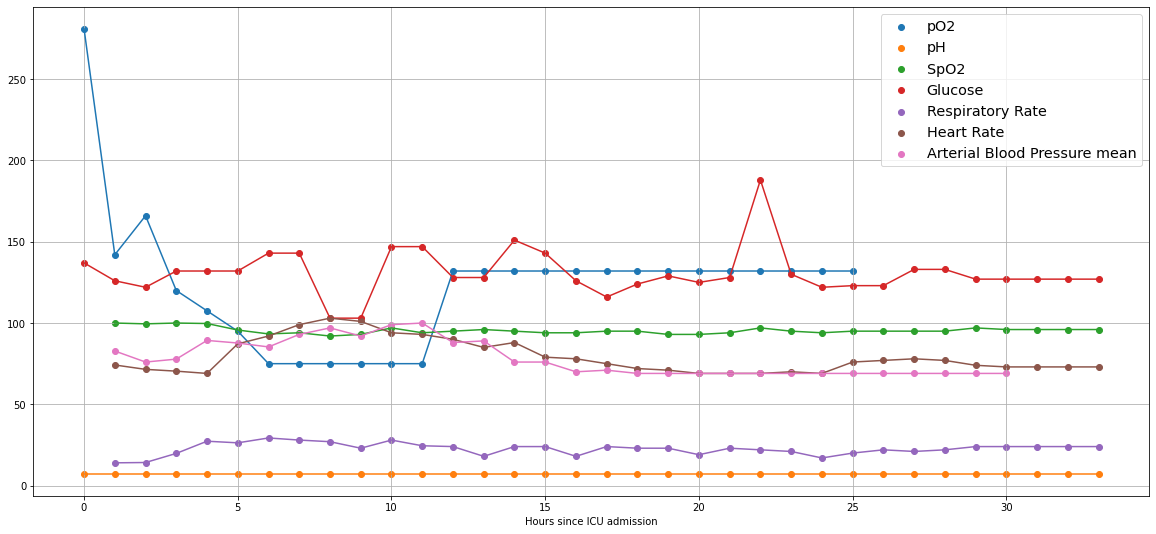

In [27]:
ICUstayID = 200062

all_series = dataframe_from_csv(os.path.join(path_timeseries, str(ICUstayID), 'imputed_timeseries.csv'))

vitals = ['pO2','pH','SpO2', 'Glucose', 'Respiratory Rate', 'Heart Rate', 'Arterial Blood Pressure mean']

hours = all_series.loc[all_series.ICUSTAY_ID == ICUstayID].Bins.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in vitals:
    ax.scatter(all_series.loc[all_series.ICUSTAY_ID == ICUstayID,'Bins'], all_series.loc[all_series.ICUSTAY_ID == ICUstayID,col])
    ax.legend(vitals, fontsize='x-large')
    plt.xlabel('Hours since ICU admission')
    
for col in vitals:    
    ax.plot(all_series.loc[all_series.ICUSTAY_ID == ICUstayID,'Bins'], all_series.loc[all_series.ICUSTAY_ID == ICUstayID,col])
plt.grid()    
plt.show()

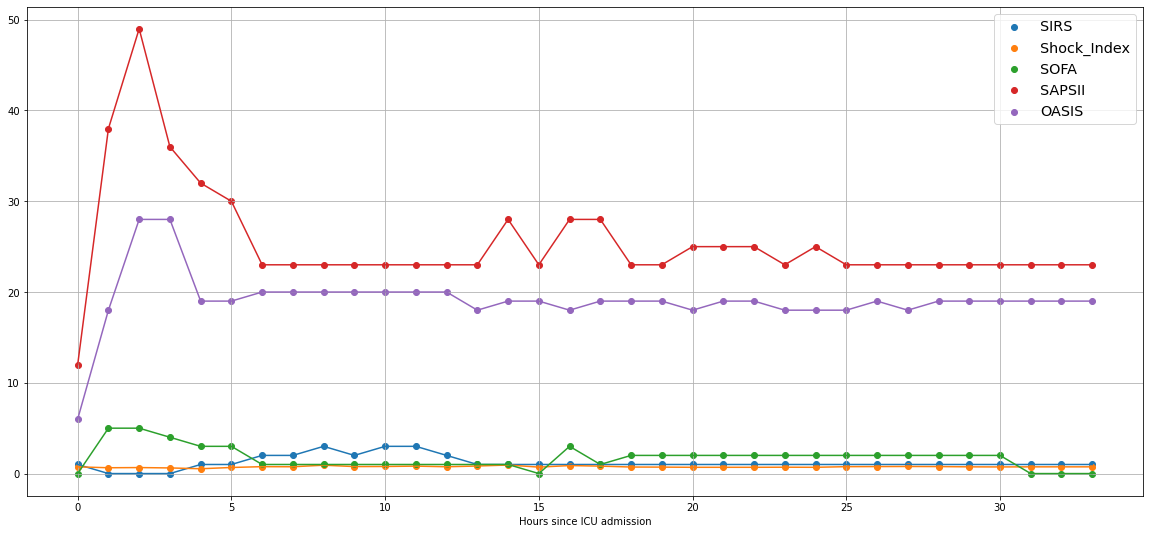

In [28]:
scores = ['SIRS','Shock_Index', 'SOFA', 'SAPSII', 'OASIS']

hours = all_series.loc[all_series.ICUSTAY_ID == ICUstayID].Bins.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in scores:
    ax.scatter(all_series.loc[all_series.ICUSTAY_ID == ICUstayID,'Bins'], all_series.loc[all_series.ICUSTAY_ID == ICUstayID,col])
    ax.legend(scores, fontsize='x-large')
    plt.xlabel('Hours since ICU admission')
    
for col in scores:    
    ax.plot(all_series.loc[all_series.ICUSTAY_ID == ICUstayID,'Bins'], all_series.loc[all_series.ICUSTAY_ID == ICUstayID,col])
plt.grid()    
plt.show()

### Check Percentage of Missingness 

In [45]:
all_stays  = pd.Series(os.listdir(path_timeseries))
all_filenames = []

for stay_id in (all_stays):
    df_file = os.path.join(path_timeseries, str(stay_id), 'timeseries.csv')
    all_filenames.append(df_file)
    
all_series = pd.concat([pd.read_csv(f) for f in all_filenames if os.path.exists(f)])
all_series.head(2)

In [ ]:
all_stays  = pd.Series(os.listdir(path_timeseries))
all_filenames = []

for stay_id in (all_stays):
    df_file = os.path.join(path_timeseries, str(stay_id), 'timeseries.csv')
    all_filenames.append(df_file)
    
random_filenames = random.choices(all_filenames, k=5000)

all_series = pd.concat([pd.read_csv(f) for f in random_filenames if os.path.exists(f)])
all_series.head(2)

In [ ]:
print(all_series.patientunitstayid.nunique())
print(all_series.shape)

### Missing Value

In [ ]:
missing_value_df = all_series.groupby('ICUSTAY_ID').apply(lambda x: x.isnull().all())
missing_value_df.drop(columns=['ICUSTAY_ID'], inplace=True)
missing_value_df = missing_value_df.reset_index()
missing_value_df = missing_value_df.replace(True, np.nan)
percent_missing = missing_value_df.isnull().sum() * 100 / len(missing_value_df)
missing_value_perc = pd.DataFrame({'column_name': missing_value_df.columns, 'percent_missing': percent_missing})
missing_value_perc.sort_values('percent_missing', inplace=True)
missing_value_perc.reset_index(inplace=True, drop=True)

In [ ]:
missing_value_perc.tail(3)